In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
%matplotlib inline
import tensorflow as tf
import keras
import glob
import cv2
import pickle, datetime

from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, ZeroPadding2D
from keras.layers import LSTM, Input, TimeDistributed, Convolution2D, Activation
from keras.optimizers import RMSprop, SGD
from keras.layers import BatchNormalization
from keras.utils import to_categorical
from keras import optimizers
from keras.preprocessing import sequence
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.models import load_model

from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
import glob
print(os.listdir("../MRI_DATASET/"))



['Testing', 'Training']


In [ ]:
import glob
import os
import cv2
import numpy as np

# Load training images and labels
train_images = []
train_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Training', '*')):
    label = os.path.basename(directory_path)
    print("Training label found:", label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            train_images.append(img)
            train_labels.append(label)

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels)

print(f'Loaded {len(train_images)} training images with labels {train_labels}')
label_to_id = {v: i for i, v in enumerate(np.unique(train_labels))}
id_to_label = {v: k for k, v in label_to_id.items()}
train_label_ids = np.array([label_to_id[x] for x in train_labels])

print("Label to ID mapping:", label_to_id)
print("ID to Label mapping:", id_to_label)

# Load testing images and labels
test_images = []
test_labels = []

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Testing', '*')):
    label = os.path.basename(directory_path)
    print("Testing label found:", label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            test_images.append(img)
            test_labels.append(label)

test_images = np.array(test_images, dtype=np.float32)
test_labels = np.array(test_labels)

print(f'Loaded {len(test_images)} testing images with labels {test_labels}')
test_label_ids = np.array([label_to_id[x] for x in test_labels])


Training label found: glioma
Training label found: meningioma
Training label found: notumor
Training label found: pituitary
Loaded 6984 training images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']
Label to ID mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
ID to Label mapping: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}
Testing label found: glioma
Testing label found: meningioma
Testing label found: notumor
Testing label found: pituitary
Loaded 2063 testing images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [2]:
train_images = []
train_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Training', '*')):
    label = os.path.basename(directory_path)
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            train_images.append(img)
            train_labels.append(label)

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels)

print(f'Loaded {len(train_images)} images with labels {train_labels}')
label_to_id = {v:i for i,v in enumerate(np.unique(train_labels))}
id_to_label = {v: k for k, v in label_to_id.items()}
train_label_ids = np.array([label_to_id[x] for x in train_labels])


glioma
meningioma
notumor
pituitary
Loaded 6984 images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [3]:
test_images = []
test_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Testing', '*')):
    label = os.path.basename(directory_path)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            test_images.append(img)
            test_labels.append(label)

test_images = np.array(test_images, dtype=np.float32)
test_labels = np.array(test_labels)

print(f'Loaded {len(test_images)} images with labels {test_labels}')
test_label_ids = np.array([label_to_id[x] for x in test_labels])


Loaded 2063 images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [4]:
from keras.applications import InceptionV3

In [5]:
inc = InceptionV3(input_shape = (128,128,3), weights='imagenet', include_top = False)

In [6]:
for i in inc.layers:
    i.trainable = False

In [7]:
n_classes = 4

In [21]:
x = Flatten()(inc.output)
#x = Dense(512, activation='relu')(x)
#x = layers.Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(n_classes, activation='softmax')(x)

In [22]:
from keras.models import Model

In [23]:
# Create the final model
inc_model = Model(inputs=inc.input, outputs=output)

In [24]:
# Compile the model
inc_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
X_normalized = np.array(train_images / 255.0 - 0.5 )
X_normalized_test = np.array(test_images / 255.0 - 0.5 )

label_binarizer = LabelBinarizer()
y_one_hot = label_binarizer.fit_transform(train_label_ids)
y_one_hot_test = label_binarizer.fit_transform(test_label_ids)

In [26]:
inc_model.fit(X_normalized, y_one_hot, batch_size=5, epochs=10,verbose=1, validation_data=(X_normalized_test,y_one_hot_test))

Epoch 1/10
1397/1397 [==============================] - 243s 159ms/step - loss: 1.2368 - accuracy: 0.6193 - val_loss: 0.6662 - val_accuracy: 0.7426
Epoch 2/10
1397/1397 [==============================] - 203s 145ms/step - loss: 0.7894 - accuracy: 0.6826 - val_loss: 0.5290 - val_accuracy: 0.8187
Epoch 3/10
1397/1397 [==============================] - 204s 146ms/step - loss: 0.7193 - accuracy: 0.7082 - val_loss: 0.5320 - val_accuracy: 0.7925
Epoch 4/10
1397/1397 [==============================] - 204s 146ms/step - loss: 0.6785 - accuracy: 0.7249 - val_loss: 0.4825 - val_accuracy: 0.8274
Epoch 5/10
1397/1397 [==============================] - 199s 143ms/step - loss: 0.6187 - accuracy: 0.7530 - val_loss: 0.4557 - val_accuracy: 0.8376
Epoch 6/10
1397/1397 [==============================] - 202s 144ms/step - loss: 0.5908 - accuracy: 0.7668 - val_loss: 0.4393 - val_accuracy: 0.8478
Epoch 7/10
1397/1397 [==============================] - 204s 146ms/step - loss: 0.5676 - accuracy: 0.7789 - val_

In [27]:
inc_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 63, 63, 32)           864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 63, 63, 32)           96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 63, 63, 32)           0         ['batch_normalization[0]

In [28]:
inc_model.save('inc_ensemble.h5')

C:\Users\aduser\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [31]:
layer_name = 'dense_2'
FC_layer_model = Model(inputs=inc_model.input, outputs=inc_model.get_layer(layer_name).output)

features = np.zeros(shape=(train_images.shape[0], 256))
i = 0
for directory_path in glob.glob("../MRI_DATASET/Training/*"):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)    
            img = cv2.resize(img, (128, 128))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img = np.expand_dims(img, axis=0)
            FC_output = FC_layer_model.predict(img)
            features[i] = FC_output
            i += 1

np.save('features', features)

1/1 [==============================] - 0s 86ms/step


In [32]:
train_features = pd.DataFrame(data=features)
train_label_ids = np.array([label_to_id[x] for x in train_labels])

In [33]:
features_test = np.zeros(shape=(test_images.shape[0], 256))
i = 0
for directory_path in glob.glob("../MRI_DATASET/Testing/*"):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)    
            img = cv2.resize(img, (128, 128))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img = np.expand_dims(img, axis=0)
            FC_output = FC_layer_model.predict(img)
            features_test[i] = FC_output
            i += 1

test_features = pd.DataFrame(data=features_test)
test_label_ids = np.array([label_to_id[x] for x in test_labels])

1/1 [==============================] - 0s 80ms/step


In [34]:
np.save('test_features', test_features)

In [35]:
rf = RandomForestClassifier(n_estimators=20, random_state=42, max_features=4)
rf.fit(train_features, train_label_ids)

RandomForestClassifier(max_features=4, n_estimators=20, random_state=42)

In [36]:
predictions_rf = rf.predict(test_features)
accuracy = accuracy_score(predictions_rf, test_label_ids)
print('Accuracy:', accuracy * 100, '%.')

Accuracy: 74.64857004362578 %.


In [37]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

In [38]:
# Generate the confusion matrix for Random Forest
conf_matrix_rf = confusion_matrix(predictions_rf, test_label_ids)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Confusion Matrix:
[[254  60  20  39]
 [141 384  27  25]
 [ 38  37 479  17]
 [ 71  29  19 423]]


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# Generate the classification report for Random Forest
class_report_rf = classification_report(test_label_ids, predictions_rf)
print("\nRandom Forest Classification Report:")
print(class_report_rf)


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.50      0.58       504
           1       0.67      0.75      0.71       510
           2       0.84      0.88      0.86       545
           3       0.78      0.84      0.81       504

    accuracy                           0.75      2063
   macro avg       0.74      0.74      0.74      2063
weighted avg       0.74      0.75      0.74      2063



In [41]:
import numpy as np 
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
dt = DecisionTreeClassifier()
dt.fit (train_features, train_label_ids)

DecisionTreeClassifier()

In [43]:
predictions_dt = dt.predict(test_features)
accuracy_dt = accuracy_score(predictions_dt, test_label_ids)
print('Accuracy:', accuracy_dt * 100, '%.')

Accuracy: 68.05622879301988 %.


In [44]:
# Generate the confusion matrix for Random Forest
conf_matrix_dt = confusion_matrix(predictions_dt, test_label_ids)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_dt)

Decision Tree Confusion Matrix:
[[220  56  29  55]
 [164 370  53  38]
 [ 49  36 440  37]
 [ 71  48  23 374]]


In [45]:
svm = SVC()
svm.fit (train_features, train_label_ids)

SVC()

In [46]:
predictions_svm = svm.predict(test_features)
accuracy_svm = accuracy_score(predictions_svm, test_label_ids)
print('Accuracy:', accuracy_svm * 100, '%.')

Accuracy: 57.343674260785264 %.


In [47]:
# Generate the confusion matrix for Random Forest
conf_matrix_svm = confusion_matrix(predictions_svm, test_label_ids)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_svm)

Decision Tree Confusion Matrix:
[[242  99  57  65]
 [142 213  99  27]
 [ 32 136 343  27]
 [ 88  62  46 385]]


In [48]:
# Load the features
features = np.load('features.npy')
test_features = np.load('test_features.npy')

In [49]:
# Create DataFrames
train_features = pd.DataFrame(data=features)
test_features = pd.DataFrame(data=test_features)

In [50]:
# Define the classifiers
rf = RandomForestClassifier(n_estimators=20, random_state=42, max_features=4)
dt = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)

In [51]:
# Train the classifiers
rf.fit(train_features, train_label_ids)
dt.fit(train_features, train_label_ids)
svm.fit(train_features, train_label_ids)

SVC(probability=True, random_state=42)

In [52]:
# Combine classifiers into a VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('rf', rf), 
    ('dt', dt), 
    ('svm', svm)
], voting='soft')

In [53]:
# Train the VotingClassifier
ensemble_model.fit(train_features, train_label_ids)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_features=4,
                                                     n_estimators=20,
                                                     random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))],
                 voting='soft')

In [54]:
# Predict on the test data
predictions_ensemble = ensemble_model.predict(test_features)

In [55]:
# Evaluate the ensemble model
accuracy = accuracy_score(test_label_ids, predictions_ensemble)
print('Ensemble Model Accuracy:', accuracy*100, '%')

Ensemble Model Accuracy: 71.20698012603005 %


In [56]:
# Generate the confusion matrix
conf_matrix_ensemble = confusion_matrix(test_label_ids, predictions_ensemble)
print("Ensemble Model Confusion Matrix:")
print(conf_matrix_ensemble)

Ensemble Model Confusion Matrix:
[[225 148  46  85]
 [ 48 376  41  45]
 [ 15  40 468  22]
 [ 43  32  29 400]]


In [57]:
# Generate the classification report
class_report = classification_report(test_label_ids, predictions_ensemble)
print("\nEnsemble Model Classification Report:")
print(class_report)


Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.45      0.54       504
           1       0.63      0.74      0.68       510
           2       0.80      0.86      0.83       545
           3       0.72      0.79      0.76       504

    accuracy                           0.71      2063
   macro avg       0.71      0.71      0.70      2063
weighted avg       0.71      0.71      0.70      2063



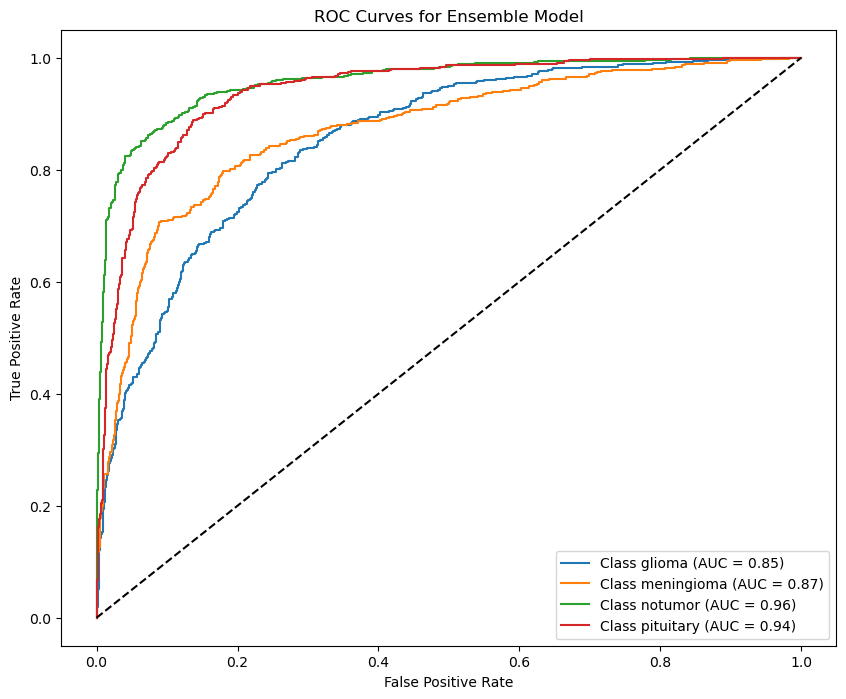

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curves
y_test_binarized = label_binarize(test_label_ids, classes=[0, 1, 2, 3])

# Get prediction probabilities for ROC curve
y_pred_prob = ensemble_model.predict_proba(test_features)

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {id_to_label[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Ensemble Model')
plt.legend(loc='lower right')
plt.show()


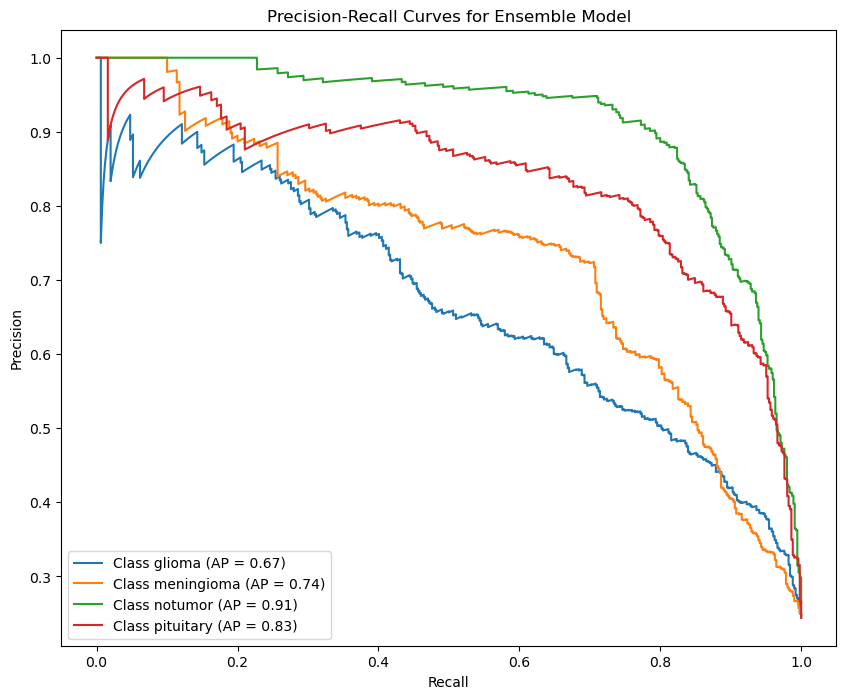

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot Precision-Recall curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    avg_precision = average_precision_score(y_test_binarized[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'Class {id_to_label[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Ensemble Model')
plt.legend(loc='lower left')
plt.show()


In [61]:
import joblib

In [62]:
joblib.dump(ensemble_model, 'inc_ensemble_model.pkl')

['inc_ensemble_model.pkl']